In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
from pathlib import Path 
import re
import cv2
import easyocr

In [2]:
import yaml
CONFIG_PATH = "../../configs/laptop.yaml" 
#環境によってパスを変える!!

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

device = cfg["runtime"]["device"]
sample_mode = cfg["runtime"]["sample_mode"]
use_gpu = cfg["runtime"]["use_gpu"]
print(cfg)


{'runtime': {'device': 'cpu', 'sample_mode': True, 'use_gpu': False}}


In [17]:
vod_title = "M8 vs. EDG - VALORANT Masters Santiago - SWISS"
video_path = Path(f"../../data/vods/{vod_title}.mp4")
csv_path = Path(f"../../data/processed/round_labels/{vod_title}_round_labels_fixed.csv")
df = pd.read_csv(csv_path)
reader = easyocr.Reader(["en"],gpu=False)

Using CPU. Note: This module is much faster with a GPU.


In [8]:
df.columns

Index(['value', 'start_sec', 'end_sec', 'n_samples', 'mean_diff', 'min_diff',
       'max_diff', 'duration_sec', 't_sec', 't_min', 'left_score',
       'right_score', 'left_score_candidates', 'right_score_candidates',
       'score_total', 'round_no_from_score', 'map_no', 'round_no',
       'left_win_label', 'round_ocr_start_samples', 'round_ocr_end_samples',
       'round_no_ocr_start', 'round_no_ocr_end', 'prev_round_no_ocr',
       'prev_end_like', 'gap_from_prev', 'ocr_step', 'sequence_status',
       'action_candidate', 'fix_applied', 'needs_review', 'map'],
      dtype='str')

In [9]:
time_df = df[["start_sec","end_sec"]]

In [3]:
def normalize_timer_text(timer_text: str) -> str:
    if pd.isna(timer_text):
        return ""

    s = str(timer_text).strip()

    # OCRのよくある誤認補正
    s = s.replace("O", "0").replace("o", "0")
    s = s.replace("I", "1").replace("l", "1")

    # コロン誤認を補正
    s = s.replace(".", ":").replace(",", ":").replace(";", ":")

    # 空白を消す
    s = s.replace(" ", "")

    return s

def parse_timer_text_to_sec(timer_text: str):
    if pd.isna(timer_text):
        return np.nan

    s = normalize_timer_text(timer_text)

    # まず普通の m:ss を試す
    m = re.search(r'^(\d{1,2}):(\d{2})$', s)
    if m:
        minute = int(m.group(1))
        second = int(m.group(2))
        if second < 60:
            return minute * 60 + second
        return np.nan

    # コロンが落ちて数字だけになった場合
    digits = "".join(ch for ch in s if ch.isdigit())

    if len(digits) == 3:
        minute = int(digits[0])
        second = int(digits[1:])
    elif len(digits) == 4:
        minute = int(digits[:-2])
        second = int(digits[-2:])
    else:
        return np.nan

    if second >= 60:
        return np.nan

    return minute * 60 + second

def add_padding(img, pad=10, value=255):
    return cv2.copyMakeBorder(
        img,
        pad, pad, pad, pad,
        cv2.BORDER_CONSTANT,
        value=value
    )

def crop_timer_region(frame):
    """
    タイマー領域を切り出す
    """
    h, w = frame.shape[:2]

    # 仮の例: 画面上中央あたり
    x1 = int(w * 0.48)
    x2 = int(w * 0.52)
    y1 = int(h * 0.025)
    y2 = int(h * 0.06)

    return frame[y1:y2, x1:x2]


def preprocess_for_ocr(crop):
    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    gray = cv2.resize(gray, None, fx=3, fy=3, interpolation=cv2.INTER_CUBIC)

    # 2値化
    _, th = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return th


def read_timer_from_frame(frame, reader):
    crop = crop_timer_region(frame)
    proc = preprocess_for_ocr(crop)

    results = reader.readtext(proc, detail=0, paragraph=False)
    text = "".join(results).strip() if results else ""

    return {
        "timer_text": text,
        "timer_sec": parse_timer_text_to_sec(text),
        "raw_text": results
    }

In [10]:
def read_frame_at_sec(video_path, t_sec):
    cap = cv2.VideoCapture(str(video_path))
    fps = cap.get(cv2.CAP_PROP_FPS)
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(t_sec * fps))
    ret, frame = cap.read()
    cap.release()

    if not ret:
        return None

    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    return frame

In [24]:
row = time_df.iloc[8]

start = row["start_sec"]
end = row["end_sec"]

frame = read_frame_at_sec(video_path,start)
texts = read_timer_from_frame(frame,reader)
search_start = start + texts["timer_sec"] - 1
frame_start = read_frame_at_sec(video_path,search_start)


c:\Users\ryo16\Desktop\valorant-\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


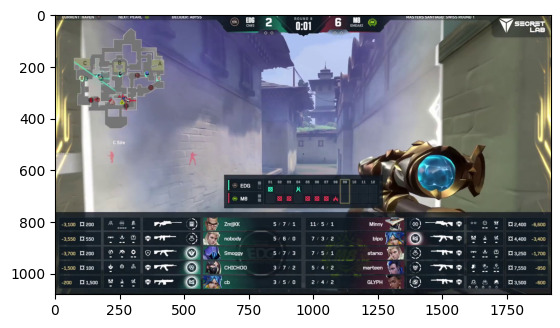

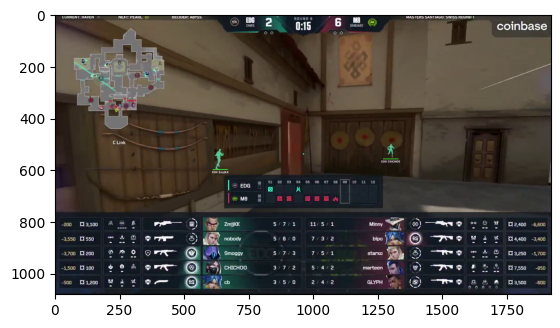

{'timer_text': '0.15', 'timer_sec': 15, 'raw_text': ['0.15']}


In [25]:
plt.imshow(frame_start)
plt.show()
plt.imshow(frame)
plt.show()
print(texts)